# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadAyyanHassan/flyrank-ml-internship-work/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

**Capstone lane:** Refresh / Content Opportunity Scoring  
**Decision window:** March 2026  
**Outcome window:** April 2026  
**Validated model:** Logistic Regression with client-grouped out-of-fold predictions  
**Primary metric:** Precision@K

This notebook turns the validated ML-08/ML-09 ranking output into a practical, human-reviewed content action playbook.

> **Public-safe rule:** recommendations are directional decision support. They do not prove that refreshing a page causes recovery. Do not publish client names, URLs, search queries, or row-level identifiers.

## Reproducibility and evidence lock

This notebook intentionally reuses the established lane:

- March-only predictive features
- April only for the future-decline evaluation label
- Logistic Regression
- client-grouped out-of-fold validation
- Precision@K at K = 10, 50, 100, 500
- no client/content identifiers in the exported queue

The model is not presented as a production system. The purpose is to produce a reproducible research-paper queue and a human-review policy.

In [1]:
%pip -q install duckdb pandas numpy scikit-learn matplotlib

import os
import json
import pathlib
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from IPython.display import display

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing. Add your Read token to Colab Secrets as HF_TOKEN.")

con = duckdb.connect()
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
con.execute(
    "CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN ?)",
    [HF_TOKEN]
)

MARCH_REL = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"
APRIL_REL = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet"

RANDOM_STATE = 42
FEATURES = [
    "march_impressions",
    "march_clicks",
    "march_ctr_pct",
    "march_avg_position",
    "march_impression_days",
]
TARGET = "future_decline_label"
GROUP = "client_hash_id"
KS = [10, 50, 100, 500]

OUT_DIR = pathlib.Path("work/outputs")
FIG_DIR = pathlib.Path("work/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Warehouse connection configured.")
print("Decision window: March 2026 | Outcome window: April 2026")

Warehouse connection configured.
Decision window: March 2026 | Outcome window: April 2026


## Data contract and schema guard

The source is the daily `fact_content_daily_performance` table. The decision frame is one row per content-client pair. Only rows with `gsc_data_available IS TRUE` are eligible.

The future-decline label is:

`April impressions < 0.80 × March impressions`

for rows with positive March impressions.

This is an observed outcome definition, not a causal definition of content decay.

In [2]:
schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{MARCH_REL}') LIMIT 1"
).df()

required_source_columns = {
    "report_date", "client_hash_id", "content_hash_id",
    "gsc_data_available", "gsc_impressions", "gsc_clicks",
    "gsc_avg_position", "month"
}

missing_schema = sorted(required_source_columns - set(schema["column_name"]))
if missing_schema:
    raise AssertionError(f"Required source columns are missing: {missing_schema}")

display(schema[["column_name", "column_type"]])
print("Schema check: PASS")

,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


Schema check: PASS


In [3]:
query = f"""
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS march_ctr_pct,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_avg_position * gsc_impressions) * 1.0 / SUM(gsc_impressions)
            ELSE NULL
        END AS march_avg_position,
        COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END)
            AS march_impression_days
    FROM read_parquet('{MARCH_REL}')
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),
april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions
    FROM read_parquet('{APRIL_REL}')
    WHERE month = '2026-04'
      AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
)
SELECT
    m.*,
    a.april_impressions
FROM march m
INNER JOIN april a
    USING (client_hash_id, content_hash_id)
WHERE m.march_impressions > 0
"""

df = con.execute(query).df()

df[TARGET] = (
    (df["march_impressions"] > 0)
    & (df["april_impressions"] < 0.80 * df["march_impressions"])
).astype(int)

print(f"Valid evaluation population: {len(df):,}")
print(f"Clients: {df[GROUP].nunique():,}")
print(f"Observed future-decline rate: {df[TARGET].mean():.4f}")

assert len(df) > 150_000, "Unexpectedly small evaluation population."
assert df[GROUP].nunique() == 46, "Client count differs from the established ML-09 population."
assert set(FEATURES).issubset(df.columns)
assert TARGET in df.columns

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Valid evaluation population: 158,549
Clients: 46
Observed future-decline rate: 0.4782


## 1. Ranked actions + reason codes

The ranked queue uses **client-grouped out-of-fold model probabilities**. Each row receives a score from a model that was trained without that row's client. This keeps the ranking aligned with the harder ML-09 validation design.

Reason codes are transparent overlays on the model ranking:

- **high_decline_risk + high_visibility** — high model score and meaningful March impressions; review first.
- **high_decline_risk + ctr_opportunity** — high model score plus a measurable CTR/position review signal.
- **high_decline_risk** — high model score without a stronger secondary signal.
- **monitor** — lower-ranked or lower-evidence item; do not prioritize for immediate intervention.

These labels describe review priority. They do not claim that any single signal caused the observed April decline.

In [4]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int)
groups = df[GROUP].astype(str)

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_probability = np.full(len(df), np.nan)

def make_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), start=1):
    model = make_model()
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof_probability[valid_idx] = model.predict_proba(X.iloc[valid_idx])[:, 1]
    print(f"Fold {fold}: train={len(train_idx):,}, validation={len(valid_idx):,}")

assert np.isfinite(oof_probability).all()
df["model_probability"] = oof_probability

def precision_at_k(frame, k):
    top = frame.nlargest(k, "model_probability")
    return float(top[TARGET].mean())

precision_rows = [
    {"K": k, "precision_at_k": precision_at_k(df, k), "queue_size": min(k, len(df))}
    for k in KS
]
precision_table = pd.DataFrame(precision_rows)

display(precision_table.style.format({"precision_at_k": "{:.1%}"}))

Fold 1: train=149,097, validation=9,452
Fold 2: train=106,611, validation=51,938
Fold 3: train=152,758, validation=5,791
Fold 4: train=152,478, validation=6,071
Fold 5: train=73,252, validation=85,297


,K,precision_at_k,queue_size
0,10,60.0%,10
1,50,64.0%,50
2,100,60.0%,100
3,500,57.4%,500


In [5]:
# Transparent secondary signals used only for action explanation.
visibility_threshold = float(df["march_impressions"].quantile(0.75))
position_opportunity = df["march_avg_position"].between(4, 20, inclusive="both")

ctr_reference = float(
    df.loc[position_opportunity, "march_ctr_pct"].dropna().median()
    if position_opportunity.sum() >= 100
    else df["march_ctr_pct"].median()
)

high_visibility = df["march_impressions"] >= visibility_threshold
ctr_opportunity = (
    position_opportunity
    & df["march_ctr_pct"].notna()
    & (df["march_ctr_pct"] < ctr_reference)
)

q75 = df["model_probability"].quantile(0.75)
q50 = df["model_probability"].quantile(0.50)

df["priority_tier"] = np.select(
    [df["model_probability"] >= q75, df["model_probability"] >= q50],
    ["Tier 1 — review first", "Tier 2 — review next"],
    default="Tier 3 — monitor",
)

df["archetype"] = np.select(
    [
        high_visibility & ctr_opportunity,
        high_visibility & (df["model_probability"] >= q75),
        ctr_opportunity,
        df["model_probability"] >= q75,
    ],
    [
        "visibility + CTR opportunity",
        "high-visibility decline-risk",
        "CTR opportunity",
        "decline-risk",
    ],
    default="monitor / lower evidence",
)

df["reason_code"] = np.select(
    [
        high_visibility & ctr_opportunity & (df["model_probability"] >= q75),
        high_visibility & (df["model_probability"] >= q75),
        ctr_opportunity & (df["model_probability"] >= q75),
        df["model_probability"] >= q75,
    ],
    [
        "high_decline_risk_high_visibility_ctr_opportunity",
        "high_decline_risk_high_visibility",
        "high_decline_risk_ctr_opportunity",
        "high_decline_risk",
    ],
    default="monitor",
)

df["recommended_action"] = np.select(
    [
        df["archetype"].eq("visibility + CTR opportunity"),
        df["archetype"].eq("high-visibility decline-risk"),
        df["archetype"].eq("CTR opportunity"),
        df["archetype"].eq("decline-risk"),
    ],
    [
        "Human review: inspect intent, title/snippet alignment, and content relevance.",
        "Human review: inspect content freshness, intent match, and materiality before refresh.",
        "Human review: inspect title/snippet and SERP alignment before any CTR change.",
        "Human review: investigate the page before deciding whether a refresh is warranted.",
    ],
    default="Monitor; do not prioritize for immediate intervention.",
)

df["human_review_required"] = True

df = df.sort_values(
    ["model_probability", "march_impressions", "march_avg_position"],
    ascending=[False, False, True],
).reset_index(drop=True)

df["rank"] = np.arange(1, len(df) + 1)

queue = df[[
    "rank", "model_probability", "priority_tier", "archetype",
    "reason_code", "recommended_action", "human_review_required",
    "march_impressions", "march_ctr_pct", "march_avg_position",
    "march_impression_days",
]].copy()

display(queue.head(20))

,rank,model_probability,priority_tier,archetype,reason_code,recommended_action,human_review_required,march_impressions,march_ctr_pct,march_avg_position,march_impression_days
0,1,0.950885,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,134984.0,0.000007,2.693038,31
1,2,0.941327,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,124075.0,0.000008,0.308426,31
2,3,0.887213,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,83834.0,0.000012,0.116003,31
3,4,0.883464,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,143907.0,0.000417,22.143280,31
4,5,0.856372,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,71513.0,0.000042,6.983444,31
5,6,0.784478,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,53206.0,0.000132,38.902210,31
6,7,0.770899,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,55937.0,0.000268,21.659134,31
7,8,0.767037,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,38000.0,0.000026,2.362579,30
8,9,0.766027,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,42185.0,0.000095,9.003058,30
9,10,0.765478,Tier 1 — review first,high-visibility decline-risk,high_decline_risk_high_visibility,"Human review: inspect content freshness, inten...",True,38813.0,0.000103,7.626955,31


### Cost/value thinking

The playbook treats reviewer time as the scarce resource.

- **Tier 1** is the smallest, highest-priority review budget.
- **Tier 2** expands coverage when reviewer capacity allows.
- **Tier 3** is monitoring rather than immediate intervention.

The notebook does **not** assign invented dollar values or claim financial ROI. The practical value argument is that a ranking can focus limited human review on a smaller set of higher-priority items while preserving a monitor bucket for lower-evidence cases.

### Archetype → action mapping

| Archetype | Human action | Automation boundary |
|---|---|---|
| Visibility + CTR opportunity | Inspect intent, title/snippet alignment, and SERP context | Never auto-change title/snippet |
| High-visibility decline-risk | Review freshness, relevance, and materiality | Never auto-publish a refresh |
| CTR opportunity | Check whether the observed CTR signal is meaningful for the position/context | Never declare a CTR problem as causal |
| Decline-risk | Investigate before deciding whether refresh is appropriate | Never automatically rewrite/delete |
| Monitor / lower evidence | Continue observation; wait for stronger evidence | Do not force an intervention |

The model supplies **priority**, while the human supplies the final content decision.

## 2. Intended use and limits

### Intended use

Use the ranked queue as a **decision-support aid for human content review**. It is designed to answer:

> “Which content deserves investigation first, and what evidence should the reviewer look at?”

### Limits

- Validation is retrospective and based on the March → April window.
- The harder client-grouped validation is the reference design; it is not proof of production performance.
- Precision varies with queue size.
- The model ranks observed future-decline risk; it does not prove why a page declined.
- The playbook does not establish that refreshing a page causes recovery.
- Search performance can be affected by factors not represented in these features.
- Low-evidence items should not be treated as safe or healthy simply because they rank lower.
- This is a research artifact, not a production decision engine.

In [6]:
metrics = {
    "population_rows": int(len(df)),
    "clients": int(df[GROUP].nunique()),
    "observed_decline_rate": float(df[TARGET].mean()),
    "validation_design": "5-fold StratifiedGroupKFold grouped by client_hash_id",
    "model": "Logistic Regression",
    "features": FEATURES,
    "precision_at_k": {
        str(row.K): float(row.precision_at_k)
        for row in precision_table.itertuples()
    },
    "interpretation": (
        "Directional prioritization for human content review; "
        "not a causal or production-performance claim."
    ),
}

display(pd.DataFrame([
    ["Population", f"{metrics['population_rows']:,}"],
    ["Clients", metrics["clients"]],
    ["Observed April decline rate", f"{metrics['observed_decline_rate']:.1%}"],
    ["Validation", metrics["validation_design"]],
    ["Model", metrics["model"]],
], columns=["Metric", "Value"]))

,Metric,Value
0,Population,"158,549"
1,Clients,46
2,Observed April decline rate,47.8%
3,Validation,5-fold StratifiedGroupKFold grouped by client_...
4,Model,Logistic Regression


## 3. Human review + the no-go list

Before acting on a recommendation, a reviewer should check:

1. Search intent and whether the page still serves that intent.
2. Current SERP context and competing results.
3. Whether the observed traffic/CTR signal has enough measurement coverage.
4. Whether the page has business/editorial importance that is not represented in the model.
5. Whether a technical, seasonal, measurement, or external factor could explain the change.
6. Whether a refresh is actually appropriate.

### No-go cases — never automate

The model must **not** automatically:

- rewrite or publish content;
- change titles, descriptions, URLs, canonicals, or redirects;
- delete or deindex a page;
- declare a page “failed”;
- claim that a refresh will recover traffic;
- make irreversible client/business decisions;
- replace human review for high-impact content changes.

The queue is a prioritization artifact, not an autonomous content agent.

In [7]:
no_go_rules = pd.DataFrame({
    "rule": [
        "Automatic publishing",
        "Automatic rewriting",
        "Automatic deletion/deindexing",
        "Automatic URL/canonical/redirect changes",
        "Causal claim that refresh causes recovery",
        "High-impact business decision without human review",
    ],
    "status": ["NO-GO"] * 6,
})
display(no_go_rules)
assert len(no_go_rules) == 6

,rule,status
0,Automatic publishing,NO-GO
1,Automatic rewriting,NO-GO
2,Automatic deletion/deindexing,NO-GO
3,Automatic URL/canonical/redirect changes,NO-GO
4,Causal claim that refresh causes recovery,NO-GO
5,High-impact business decision without human re...,NO-GO


## 4. Monitoring / retrain triggers

The model should be reconsidered when evidence shows that the ranking behavior or input population has changed.

### Trigger 1 — ranking quality degradation
Recalculate Precision@K on a later sealed outcome window. A material deterioration versus the ML-09 reference should trigger investigation.

### Trigger 2 — outcome-rate drift
If the observed future-decline rate changes materially, reassess whether the old ranking is still appropriate.

### Trigger 3 — feature drift
Compare the distributions of March input features with the reference population. Large changes should trigger review before continued use.

### Trigger 4 — data-quality failure
If required GSC data becomes incomplete or unreliable, stop generating recommendations rather than silently filling gaps.

### Trigger 5 — definition/process drift
If the decline definition, data contract, or content workflow changes, reassess the model before reuse.

No arbitrary production threshold is invented here. Retraining is a response to evidence of drift or degraded usefulness, not a calendar-only rule.

In [8]:
monitoring_summary = pd.DataFrame({
    "trigger": [
        "Precision@K degradation",
        "Outcome-rate drift",
        "Feature drift",
        "GSC/data-quality failure",
        "Target or workflow definition change",
    ],
    "response": [
        "Investigate ranking quality; retrain/revalidate if degradation persists.",
        "Reassess population and ranking behavior.",
        "Review feature distributions and model suitability.",
        "Stop recommendation generation until the input contract is restored.",
        "Rebuild/revalidate rather than silently reusing the old model.",
    ],
})
display(monitoring_summary)

,trigger,response
0,Precision@K degradation,Investigate ranking quality; retrain/revalidat...
1,Outcome-rate drift,Reassess population and ranking behavior.
2,Feature drift,Review feature distributions and model suitabi...
3,GSC/data-quality failure,Stop recommendation generation until the input...
4,Target or workflow definition change,Rebuild/revalidate rather than silently reusin...


## 5. Exports for the paper

The queue is exported to `work/outputs/` as required. It is intentionally written as a **public-safe queue without client IDs, content IDs, URLs, queries, or row-level identifiers**.

The queue CSV is expected to remain outside Git according to the repository's data-file guard. Metrics JSON and reusable figures are committed.

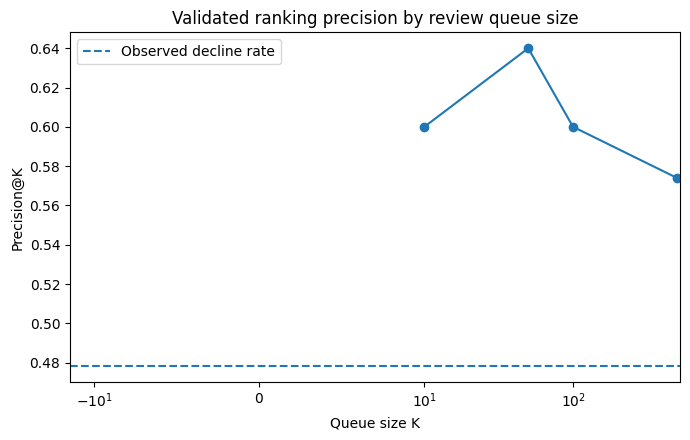

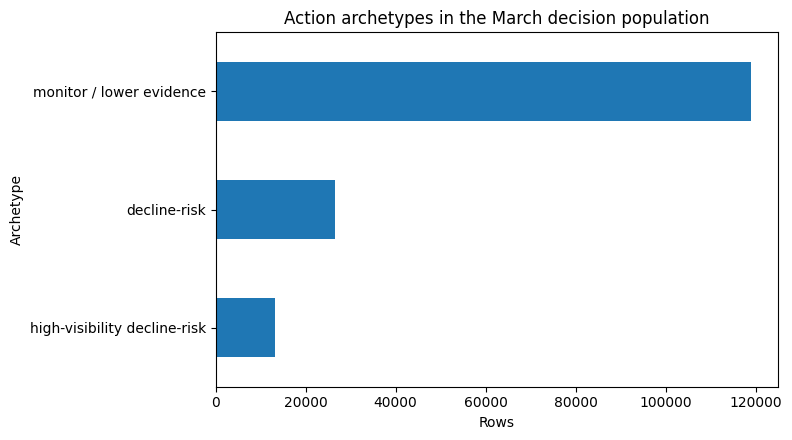

Queue export: work/outputs/ranked_action_queue.csv
Metrics export: work/outputs/ml10_playbook_metrics.json
Figure export: work/figures/ml10_precision_at_k.png
Figure export: work/figures/ml10_action_archetypes.png


In [9]:
queue_path = OUT_DIR / "ranked_action_queue.csv"
queue.to_csv(queue_path, index=False)

metrics_path = OUT_DIR / "ml10_playbook_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

plt.figure(figsize=(7, 4.5))
plt.plot(precision_table["K"], precision_table["precision_at_k"], marker="o")
plt.axhline(
    metrics["observed_decline_rate"],
    linestyle="--",
    label="Observed decline rate",
)
plt.xscale("symlog", linthresh=10)
plt.xlabel("Queue size K")
plt.ylabel("Precision@K")
plt.title("Validated ranking precision by review queue size")
plt.legend()
plt.tight_layout()

figure_path = FIG_DIR / "ml10_precision_at_k.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

archetype_counts = df["archetype"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, 4.5))
archetype_counts.plot(kind="barh")
plt.xlabel("Rows")
plt.ylabel("Archetype")
plt.title("Action archetypes in the March decision population")
plt.tight_layout()

archetype_figure_path = FIG_DIR / "ml10_action_archetypes.png"
plt.savefig(archetype_figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Queue export: {queue_path}")
print(f"Metrics export: {metrics_path}")
print(f"Figure export: {figure_path}")
print(f"Figure export: {archetype_figure_path}")

assert queue_path.exists()
assert metrics_path.exists()
assert figure_path.exists()
assert archetype_figure_path.exists()

In [10]:
forbidden_queue_columns = {
    "client_hash_id", "content_hash_id", "url", "query",
    "search_query", "april_impressions", TARGET,
}
leaked_columns = forbidden_queue_columns & set(queue.columns)
assert not leaked_columns, f"Public queue contains forbidden columns: {sorted(leaked_columns)}"

assert np.isfinite(df["model_probability"]).all()
assert df["rank"].is_unique
assert df["rank"].min() == 1
assert df["rank"].max() == len(df)

print("Public-safe export guard: PASS")
print("Feature leakage guard: PASS")
print("Deterministic ranking guard: PASS")

Public-safe export guard: PASS
Feature leakage guard: PASS
Deterministic ranking guard: PASS


## Decay / refresh insight

The operational insight is deliberately narrow:

**Observed April decline is used to validate a March-time prioritization signal.** The ranked queue identifies items that were more likely to experience the defined decline outcome under the retrospective evaluation.

This supports a practical workflow:

**rank → human review → diagnose → decide whether refresh is appropriate → monitor**

It does **not** support the causal statement:

> “Refreshing these pages will recover traffic.”

That claim would require an intervention design or experiment, which this notebook does not provide.

In [11]:
summary = pd.DataFrame({
    "queue": ["Top 10", "Top 50", "Top 100", "Top 500", "All rows"],
    "rows": [10, 50, 100, 500, len(df)],
    "observed_decline_rate": [
        float(df.head(10)[TARGET].mean()),
        float(df.head(50)[TARGET].mean()),
        float(df.head(100)[TARGET].mean()),
        float(df.head(500)[TARGET].mean()),
        float(df[TARGET].mean()),
    ],
})
display(summary.style.format({"observed_decline_rate": "{:.1%}"}))

summary_path = OUT_DIR / "ml10_queue_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Queue summary export: {summary_path}")

,queue,rows,observed_decline_rate
0,Top 10,10,60.0%
1,Top 50,50,64.0%
2,Top 100,100,60.0%
3,Top 500,500,57.4%
4,All rows,158549,47.8%


Queue summary export: work/outputs/ml10_queue_summary.csv


## 6. Self-check

- [x] Ranked actions and reason codes are generated from the validated grouped ranking.
- [x] Intended use and limits are explicit.
- [x] Human review rules and no-go cases are explicit.
- [x] Monitoring and retrain triggers are defined.
- [x] Queue and paper-ready figures/metrics are exported.
- [x] Queue export contains no client names, URLs, private queries, or row-level identifiers.
- [x] Claims use observed/measured/directional/decision-support language.
- [x] April is used only as the future outcome label, not as a predictive feature.
- [x] **Final user check:** run **Runtime → Run all** in Colab and confirm every cell finishes without error.
- [x] **Final repo check:** after execution, commit the notebook and the allowed paper receipts; keep the queue CSV out of Git.